# **MÓDULO 39 - Exercicio - Aplicando SVM**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros. A mesma que também usamos na tarefa de XGboost!


In [1]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
df = pd.read_csv('CARRO_CLIENTES.csv')
df

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0
...,...,...,...,...,...
995,863,Male,38,59000,0
996,800,Female,47,23500,0
997,407,Female,28,138500,1
998,299,Female,48,134000,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User ID       1000 non-null   int64
 1   Gender        1000 non-null   str  
 2   Age           1000 non-null   int64
 3   AnnualSalary  1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(4), str(1)
memory usage: 39.2 KB


In [4]:
df.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop(columns=['User ID'])

In [9]:
df

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0
...,...,...,...,...
995,Male,38,59000,0
996,Female,47,23500,0
997,Female,28,138500,1
998,Female,48,134000,1


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [13]:
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])
df.drop(columns=['Gender'], inplace=True)

In [14]:
df

,Age,AnnualSalary,Purchased,Gender_encoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1
...,...,...,...,...
995,38,59000,0,1
996,47,23500,0,0
997,28,138500,1,0
998,48,134000,1,0


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

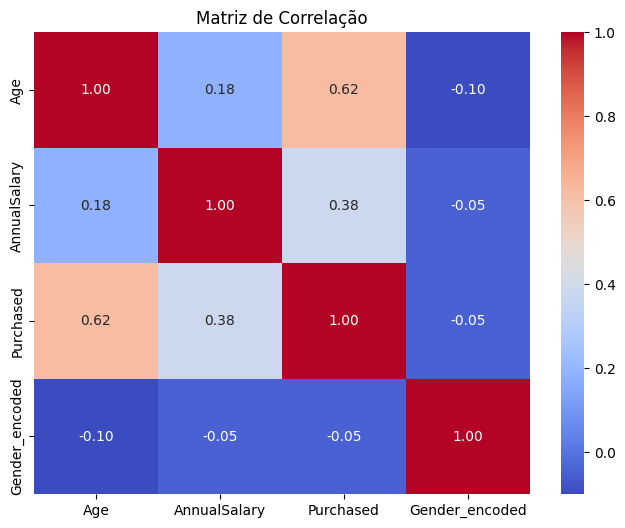

In [20]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

As duas variáveis que tem correlaçao mais forte e positiva com a variável target são idade(0.62) e salário anual(0.36). Com o aumento da idade e do salário existe uma maior tendência do purshased = 1.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [15]:
X = df.drop(columns=['Purchased'])
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [16]:
print(X_train.shape)
print(y_train.shape)

(800, 3)
(800,)


**Todos passos até aqui vocês realizaram na tarefa anterior também!**

# 5. Treino o modelo SVM com sua base de treino.
Esse modelo deve ser treinado usando o kernel linear.

In [17]:
svm_model = SVC(kernel ='linear', random_state =1, C = 1.0)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# 6. Realize as previsões para a base de teste e traga a avaliação.

In [20]:
y_pred = svm_model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       112
           1       0.85      0.69      0.76        88

    accuracy                           0.81       200
   macro avg       0.82      0.80      0.80       200
weighted avg       0.81      0.81      0.81       200

0.81


O modelo apresentou acurácia de 0.81, ou seja 81% de previsões corretas em relação ao total de previsões feitas o que é um bom resultado. Além disso um recall de 0.90 para a classe 0 mostrando que o modelo em comparação ao real acertou 90%, mas para a classe 1 0.69 de recall 69% o que não é ruim entretanto também não é ótimo.

# 7. Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
Esse modelo dedve ser treinado usando o kernel poly.

In [21]:
svm_model_poly = SVC(kernel = 'poly', random_state = 1, C = 1.0)
svm_model_poly.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
y_pred_poly = svm_model_poly.predict(X_train)
report = classification_report(y_train, y_pred_poly)
print(report)
accuracy = accuracy_score(y_train, y_pred_poly)
print(accuracy)

              precision    recall  f1-score   support

           0       0.73      0.95      0.82       486
           1       0.86      0.44      0.58       314

    accuracy                           0.75       800
   macro avg       0.79      0.70      0.70       800
weighted avg       0.78      0.75      0.73       800

0.7525


O modelo apresentou acurácia de 0.75, ou seja 75% de previsões corretas em relação ao total de previsões feitas o que é um bom resultado. Além disso um recall de 0.95 para a classe 0 mostrando que o modelo em comparação ao real acertou 95%, mas para a classe 1 0.44 de recall 44% o que não é ruim entretanto também não é ótimo.

# 8. Qual modelo se saiu melhor? O SVM com kernel linear ou poly? Compare também com o XGboost, da atividade anterior, você obteve melhores previsões com qual dos modelos?

O modelo se saiu melhor com o kernel linear que atingiu valores menores de f1-score para cada uma das classes,e mais equilibrado na classificação dessas classes.Também ocorreu uma redução da acuracia de 0.81 com kernel linear para 0.75 com kernel poly.

Atividade Anterior XGboost:

                precision    recall    f1-score   support

           0       0.89      0.95      0.92       112
           1       0.93      0.85      0.89        88

    accuracy                           0.91       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.91      0.90       200

Atividade Atual Svm:

                 precision    recall  f1-score   support

           0       0.79      0.90      0.84       112
           1       0.85      0.69      0.76        88

    accuracy                           0.81       200
   macro avg       0.82      0.80      0.80       200
weighted avg       0.81      0.81      0.81       200


O XGBoost apresentou melhores previsões que o SVM. O XGBoost alcançou uma acurácia de 0,91 (91%), enquanto o SVM obteve 0,81 (81%). Além disso, o XGBoost apresentou F1-score de 0,92 para a classe 0 e 0,89 para a classe 1, enquanto o SVM apresentou 0,84 e 0,76.

Correção da atividade:

Bom trabalho! Você demonstrou bom entendimento sobre a aplicação dos modelos de ML, desde a preparação inicial dos dados até a comparação entre diferentes algoritmos. A forma como vocêestruturou os códigos para a limpeza dos dados, a codificação de variáveis categóricas e a visualização por meio da matriz de correlação mostra domínio das etapas essenciais da análise de dados. Além disso, a sua análise está detalhada para as métricas de avaliação e a comparação crítica com os resultados do XGBoost refletem uma ótima capacidade de interpretação dos resultados obtidos.

Dicas de melhoria

Uma ótima melhoria para algoritmos baseados em margens e distâncias, como o SVM, é aplicar a padronização nas variáveis numéricas (como idade e salário) antes do treinamento, garantindo que colunas com maiores escalas numéricas não dominem o aprendizado do modelo.
Na etapa do modelo com kernel polinomial, a avaliação foi realizada utilizando a base de treino em vez da base de teste, o que pode mascarar o desempenho real. O ideal é aplicar as previsões e métricas sempre sobre o conjunto de teste para verificar a capacidade de generalização.
Seria muito enriquecedor explorar outros tipos de kernels disponíveis no SVM, como o kernel RBF (Radial Basis Function), que lida muito bem com fronteiras de decisão complexas e não lineares nos dados.
Utilizar técnicas de otimização de parâmetros, como a variação do parâmetro de regularização `C` ou do grau no kernel polinomial, ajudaria a buscar o melhor equilíbrio entre viés e variância para melhorar as métricas de acerto.
Verificar se as classes da variável alvo estão equilibradas e, caso necessário, aplicar técnicas de reamostragem permitiria que o modelo aprendesse de forma mais justa e consistente a prever ambas as categorias.
Obs.: As dicas e sugestões não caracterizam a nota final da tarefa, são apenas para melhorar o desenvolvimento do seu trabalho ao longo do curso e na carreira profissional.

Conte comigo

Um abraço